In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import  train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix
import math

In [3]:

# --- 1. Create non-linear sine wave data ---
np.random.seed(42)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.randn(80) * 0.2 # A bit more noise


In [4]:
X

array([[0.02761059],
       [0.10292247],
       [0.17194261],
       [0.22613644],
       [0.23225206],
       [0.29041806],
       [0.32525796],
       [0.37022326],
       [0.37275322],
       [0.44246251],
       [0.48836057],
       [0.5793453 ],
       [0.61019117],
       [0.6974693 ],
       [0.70462112],
       [0.7799726 ],
       [0.7800932 ],
       [0.85262062],
       [0.90912484],
       [0.91702255],
       [0.92427228],
       [0.97991431],
       [0.99357841],
       [0.99836891],
       [1.06169555],
       [1.29389991],
       [1.35674516],
       [1.40467255],
       [1.4561457 ],
       [1.46072324],
       [1.52121121],
       [1.52306885],
       [1.55855538],
       [1.62665165],
       [1.78376663],
       [1.79232864],
       [1.83180922],
       [1.87270059],
       [1.94338645],
       [2.15972509],
       [2.20076247],
       [2.28034992],
       [2.47588455],
       [2.57117219],
       [2.60034011],
       [2.62378216],
       [2.71348042],
       [2.733

In [5]:
y

array([ 0.09385976,  0.29784988,  0.07526178,  0.18708222,  0.00890271,
        0.04711148,  0.4820584 ,  0.63307158,  0.34977893,  0.62887271,
        0.54150594,  0.41845223,  0.64530327,  0.94988736,  0.64058002,
        1.01618867,  0.17939665,  0.91738789,  0.80637572,  0.73399283,
        0.81653474,  0.43293585,  0.79404968,  0.9120111 ,  1.16876195,
        0.85825446,  0.81547966,  0.88588174,  1.17651524,  1.05969829,
        0.89281887,  1.10151475,  1.01934059,  1.19216949,  0.83699679,
        0.91002948,  0.88770746,  0.66206902,  0.99061165,  0.88374725,
        0.80907015,  0.71173536,  0.33454205,  0.45585692,  0.44666701,
        0.3345234 ,  0.38289701,  0.47762233,  0.5557943 ,  0.18642263,
        0.19926731,  0.12070939, -0.28007251,  0.07693243, -0.1581403 ,
        0.21670367, -0.42115099, -0.32797589, -0.48938673, -0.72920667,
       -0.42687092, -0.50872075, -0.51169166, -0.88819823, -0.48337804,
       -1.06394203, -0.68765173, -0.40450989, -1.0505399 , -1.04

<Axes: >

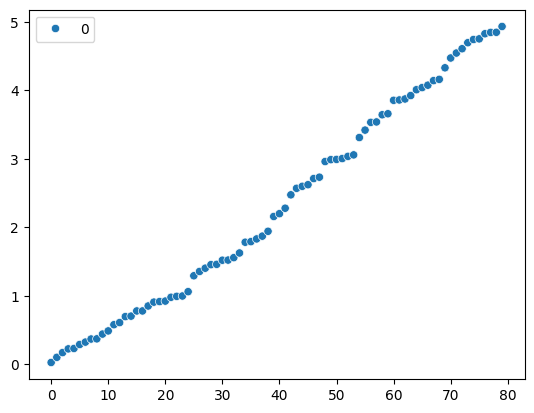

In [6]:
import seaborn as sns 

sns.scatterplot(X)



<Axes: >

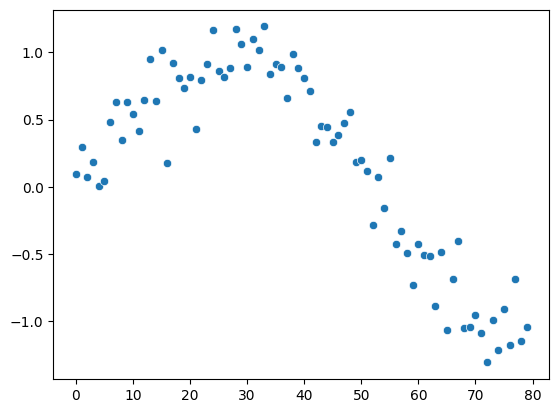

In [7]:
sns.scatterplot(y)

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.25,random_state=42)

In [15]:
ytest

array([ 0.89281887,  0.09385976,  0.79404968,  1.10151475,  0.80637572,
        1.17651524,  0.54150594, -0.95182167,  0.00890271,  0.64530327,
        0.18642263,  1.19216949, -0.40450989,  0.91002948, -1.0505399 ,
        0.3345234 , -0.98617649, -0.50872075,  0.21670367,  0.80907015])

In [9]:

# --- 2. Define the models ---
# Decision Trees are not sensitive to scaling, but using a pipeline is good practice.
# Decision Tree with controlled depth to prevent extreme overfitting
dt_pipeline = Pipeline([
    
    ('regressor', DecisionTreeRegressor(max_depth=5))
])


In [10]:

# --- 3. Train the models ---
dt_pipeline.fit(xtrain, ytrain)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction

In [11]:
pred=dt_pipeline.predict(xtest)
pred

array([ 0.95991826,  0.29784988,  0.95991826,  0.95991826,  0.710863  ,
        0.95991826,  0.50244677, -1.0641738 ,  0.18708222,  0.50244677,
        0.19926731,  0.95991826, -0.68765173,  0.82881125, -0.68765173,
        0.40499075, -1.2583893 , -0.55592308, -0.1581403 ,  0.82881125])

In [13]:
from sklearn.metrics import  mean_squared_error

from sklearn.metrics import  r2_score


mse_predictor =mean_squared_error(ytest,pred)
print("showing nearing to zero:",mse_predictor)

if mse_predictor<0.1:
    print("model well.. ")
    print("accuracy:",(r2_score(ytest,pred))*100)

showing nearing to zero: 0.03553840503038368
model well.. 
accuracy: 93.03817056058335


In [36]:
accuracy=math.sqrt(acc)
print ("units:",accuracy)
ful_ac=accuracy**0.5
print("R1:",ful_ac)

units: 0.9645629609340354
R1: 0.9821216630000763


In [ ]:
from sklearn.metrics import  r2_score


acc=r2_score(ytest,pred)
ratio=acc
print("Ratio:",ratio)
print ("accuracy:",ratio*100 ,"%")

Ratio: 0.9303817056058336
accuracy: 93.03817056058335 %


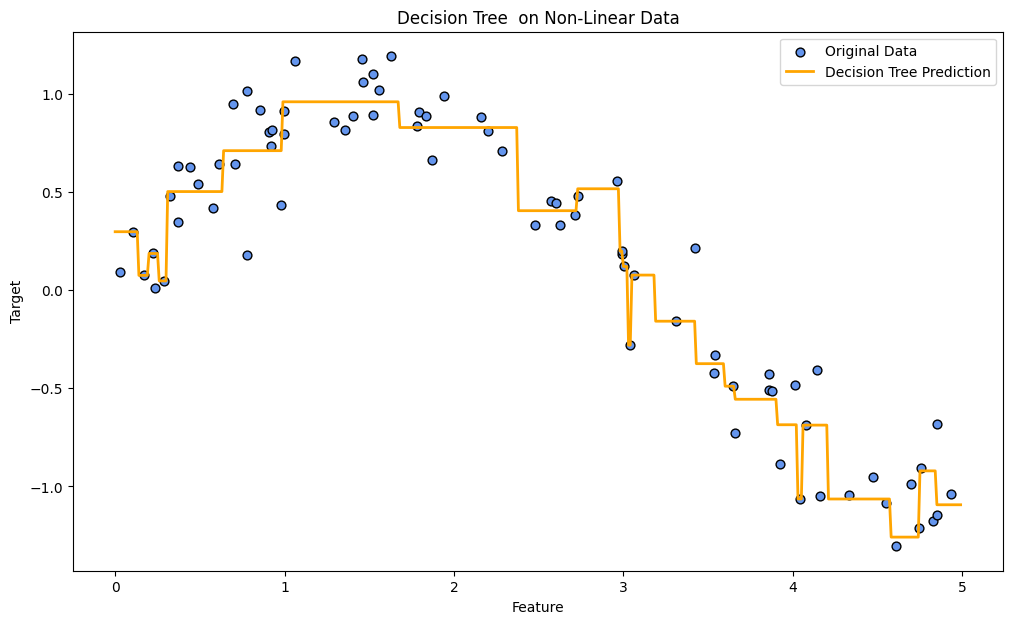

In [14]:


# --- 4. Generate predictions for visualization ---
# Create a smooth range of X values to plot the prediction lines
X_plot = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_pred_dt = dt_pipeline.predict(X_plot)


# --- 5. Plot the comparison ---s
plt.figure(figsize=(12, 7))

# Plot the original data points
plt.scatter(X, y, s=40, edgecolor="black", c="cornflowerblue", label="Original Data")

# Plot the prediction lines
plt.plot(X_plot, y_pred_dt, color="orange", linewidth=2, label="Decision Tree Prediction")
plt.title("Decision Tree  on Non-Linear Data")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

In [19]:
dt_pipeline.predict([[4.4]])

array([-1.0641738])